In [35]:
from datasets import load_dataset
import numpy as np
import pandas as pd


In [15]:
ds = load_dataset('imdb')

In [18]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [8]:
train_df = ds['train'].to_pandas();

In [16]:
train_df.sample(5)

,text,label
15121,"""Lion King 1 1/2"" is the funniest non-theatric...",1
17010,This movie is so good I could watch it all day...,1
19040,When I heard that this movie was coming out th...,1
8018,The Rookie suffers from so much. There are the...,0
17828,I thought this was an utterly charming film. T...,1


In [17]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [19]:
train_df['sentiment'] = np.where(train_df['label'] == 1, 'positive', 'negative')

In [21]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


<Axes: >

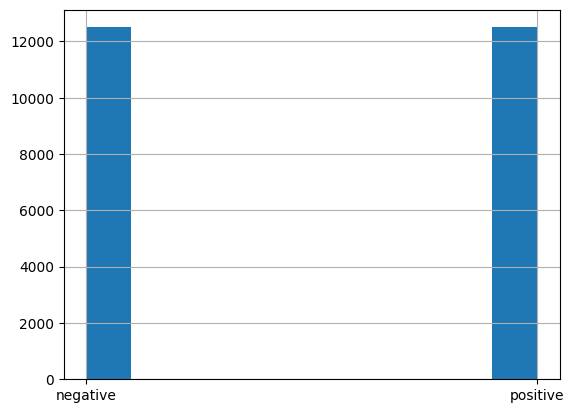

In [22]:
train_df.sentiment.hist()

In [23]:
from sklearn.model_selection import train_test_split

In [81]:
examples_df , gold_examples_df = train_test_split(train_df, test_size=0.2, random_state=123)

In [82]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [83]:
columns = ['text', 'sentiment']
gold_examples = (gold_examples_df[columns]
                 .sample(10,random_state=34)
                 .to_json(orient='records')
                 )


In [29]:
import json

In [31]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

In [39]:
user_prompt_template = """```{movie_review}```""" 

In [40]:
zero_shot_prompt_system = """
Classify the sentiment of movie reviews presented in the input as either positive or negative.
Movie reviews will be delimited by triple backticks ``` in the input
Answer only as 'positive' or 'negative'
Do not explain your answer, just give the label.
"""

In [41]:
zero_shot_prompt = [{"role": 'system', "content": zero_shot_prompt_system}] 

In [42]:
few_shot_prompt_system = """
Classify the sentiment of movie reviews presented in the input as either positive or negative.
Movie reviews will be delimited by triple backticks ``` in the input
Answer only as 'positive' or 'negative'
Do not explain your answer, just give the label.
"""

In [49]:
positive_reviews = examples_df[examples_df['sentiment'] == 'positive']
negative_reviews = examples_df[examples_df['sentiment'] == 'negative']

In [52]:
negative_reviews.shape, positive_reviews.shape


((10037, 3), (9963, 3))

In [55]:
positive_examples =  (positive_reviews[columns]
                      .sample(5)
                      .to_json(orient='records')
                      )

In [56]:
negative_examples =  (negative_reviews[columns]
                      .sample(5)
                      .to_json(orient='records')
                      )

In [58]:
json.loads(positive_examples)

[{'text': 'The first "side-story" in the universal century Gundam universe presents a refreshing new look at the war between earth and the space colonies. The focus is no longer on a small group of individuals who would go on to play pivotal roles in the conflict, but on the everyday civilian population and how the war is seen through their eyes.<br /><br />The story does contain some Gundam staples, its premise being the attempts by a ZEON squad to capture an experimental Gundam, but it the execution of the plot that made this show so interesting to watch. This series focuses on the experiences of a young boy named Alfred and the relationship between his neighbor, Christina Mckenzie who is secretly a Federation pilot and a newbie Zeon pilot named Bernie Wiseman. Alfred develops a sort of "brotherly love" for Bernie while our young Zeon pilot also falls for Christina.<br /><br />"War in the Pocket" proves that you do not need a sweeping epic tale about special individuals to make for a

In [59]:
json.loads(negative_examples)

[{'text': 'This sequel is thoroughly uneven, incoherent and rambling in "plot" (if there really is one)and tries too damned hard to be modern (ridiculous, out of period and character 21 st century style songs predominate) and cute (yawn: there are too many manufactured, belaboured jokes with animals.) The actors in his film are secondary to the juvenile plot. Even Glenn Close (and she is normally very good) sweeps through this film, parodying herself as the original De Ville and the lead from Sunset Boulevard! It\'s a film that isn\'t even good to look at. This is a very good example of a bad and pointless sequel. Even Basic Instinct 2 had a plot, characterisation and acceptable acting. This doesn\'t. It is bad.',
  'sentiment': 'negative'},
 {'text': 'Watching "Speak Easily" is painful for fans of Buster Keaton. Seeing such a phenomenal writer, actor, comic, director, and stunt man subjected to this humiliating spectacle is like seeing a Picasso used as a drop cloth, or perhaps more l

In [86]:
ex = pd.concat([positive_reviews[columns].sample(5, random_state=34), negative_reviews[columns].sample(5, random_state=34)], axis=0)

In [87]:
ex

,text,sentiment
14351,I went to see Antone Fisher not knowing what t...,positive
13676,This is a very good movie. Do you want to know...,positive
21696,Several story lines are interwoven here around...,positive
14251,"""I moved out here to get away from this kind o...",positive
16203,"Another powerful chick flick. This time, it re...",positive
2786,Do we really need any more narcissistic garbag...,negative
991,"This movie is so awful, it is hard to find the...",negative
12145,I had high hopes for Troy and I am so bitterly...,negative
11534,If I could i would give ZERO stars for this on...,negative
8372,- A film crew is shooting a horror movie in an...,negative


In [88]:
examples = ex.sample(4*2, replace=False).to_json(orient='records')

In [89]:
json.loads(examples )

[{'text': "This is a very good movie. Do you want to know the real reasons why so many here are knocking this movie? I will tell you. In this movie, you have a black criminal who outwits a white professor. A black cop who tells the white professor he is wrong for defending the black criminal and the black cop turns out to be right, thus. \x85making the white professor look stupid. It always comes down to race. This is an excellent movie. Pay no attention to the racist. If you can get over that there are characters who are played by blacks in this movie who outsmart the white characters, then you shouldn't have any problems enjoying this movie. I recommended everyone to go see this movie.",
  'sentiment': 'positive'},
 {'text': '"I moved out here to get away from this kind of thing!" The small town sheriff laments.<br /><br />"This happens a lot in Chicago?" His deputy asks.<br /><br />Well, no, not really. The plot is that a group of Martians mistake a Halloween Rebroadcast of Orson We

In [99]:
def create_examples(dataset,n=4):
    positive_reviews = dataset[dataset['sentiment'] == 'positive']
    negative_reviews = dataset[dataset['sentiment'] == 'negative']
    
    examples_df = pd.concat([positive_reviews[columns].sample(n, random_state=34), negative_reviews[columns].sample(n, random_state=34)], axis=0)
    
    examples =  examples_df.sample(2*n, replace=False).to_json(orient='records')
    return examples

In [100]:
examples_df.shape


(20000, 3)

In [101]:
examples = create_examples(examples_df, n=7)

In [102]:

json.loads(examples )

[{'text': '- A film crew is shooting a horror movie in an old, supposedly cursed house where over the years, seven people have mysteriously died. One of the crew finds an old book of spells and it looks like it would be perfect to use in some of the ritual scenes in their movie. It is reasoned that the spells in the book are better written than the script they are using. But as the book is read, the graveyard outside suddenly comes to life. Now the cast and crew are faced with real danger .<br /><br />- IMDb lists a running time of 90 minutes. For the first 60 of those minutes, nothing happens. Far too much time is spent on the movie within a movie. Are we supposed to be frightened by the horror movie that they are shooting? We already know that their movie isn\'t "real". These scares just don\'t work.<br /><br />- There are very few things to enjoy about The House of Seven Corpses. The acting is atrocious. Most of these "actors" would have trouble making a elementary school play. The 

In [118]:
def create_prompt(system_message,examples,user_prompt_template):
    prompt = [{"role": 'system', "content": system_message}]
    for example in json.loads(examples):
        review = example['text']
        sentiment = example['sentiment']
        prompt.append({"role": 'user', "content": user_prompt_template.format(movie_review=review)})
        prompt.append({"role": 'assistant', "content": f"{sentiment}"})
    return prompt

In [119]:
few_shot_examples = create_examples(examples_df, n=2)

In [ ]:
# %load (few_shot_examples)
[{"text":"This movie is so awful, it is hard to find the right words to describe it!<br \/><br \/>At first the story is so ridiculous.A narrow-minded human can write a better plot! The actors are boring and untalented, perhaps they were compelled to play in this cheesy Film.<br \/><br \/>The camera receptions of the National Forest are the only good in this whole movie. I should feel ashame, because I paid for this lousy Picture.<br \/><br \/>Hopefully nobody makes a sequel or make a similar film with such a worse storyline :-)","sentiment":"negative"},{"text":"Do we really need any more narcissistic garbage on the Baby Boomer generation? Technically, I am a Boomer, though at the time when all the \"idealistic youths\" of the '60s were reading Marx, burning their draft cards, and generally prolonging a war which destroyed tens of thousands of lives; I was still in grade school. But I remember them well, and 9 out of 10 were just moronic fools, who would believe anything as long as it was destructive.<br \/><br \/>This is just another excercise in self-importance from the kids who never really grew up.","sentiment":"negative"},{"text":"I went to see Antone Fisher not knowing what to expect and was most pleasantly surprised. The acting job by Derek Luke was outstanding and the story line was excellent. Of course Denzel Washington did his usual fine job of acting as well as directing. It makes you realized that people with mental problems CAN be helped and this movie is a perfect example of this. Don't miss this one.","sentiment":"positive"},{"text":"This is a very good movie. Do you want to know the real reasons why so many here are knocking this movie? I will tell you. In this movie, you have a black criminal who outwits a white professor. A black cop who tells the white professor he is wrong for defending the black criminal and the black cop turns out to be right, thus. \u0085making the white professor look stupid. It always comes down to race. This is an excellent movie. Pay no attention to the racist. If you can get over that there are characters who are played by blacks in this movie who outsmart the white characters, then you shouldn't have any problems enjoying this movie. I recommended everyone to go see this movie.","sentiment":"positive"}]

In [120]:
few_shot_prompt = create_prompt(few_shot_prompt_system, few_shot_examples, user_prompt_template)

In [121]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as either positive or negative.\nMovie reviews will be delimited by triple backticks ``` in the input\nAnswer only as 'positive' or 'negative'\nDo not explain your answer, just give the label.\n"},
 {'role': 'user',
  'content': "```This is a very good movie. Do you want to know the real reasons why so many here are knocking this movie? I will tell you. In this movie, you have a black criminal who outwits a white professor. A black cop who tells the white professor he is wrong for defending the black criminal and the black cop turns out to be right, thus. \x85making the white professor look stupid. It always comes down to race. This is an excellent movie. Pay no attention to the racist. If you can get over that there are characters who are played by blacks in this movie who outsmart the white characters, then you shouldn't have any problems enjoying this movie. I recommended everyone to g